Capturing Abnormal Returns/Shocks

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import plotly.express as px
import csv

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import LatentDirichletAllocation

import nltk
nltk.download('stopwords')
from textblob import TextBlob
from nltk.corpus import stopwords
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\razor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Reading Excel files
price_df = pd.read_excel('C:\\Projects\\1.NLP\\prices .xls')
event_df = pd.read_excel('C:\\Projects\\1.NLP\\merged2_OWS.xls')


In [3]:
# Selecting only six pharamaceutical companies and taking prices after 2019
price_df = price_df[price_df.ticker.isin(['BNTX', 'JNJ', 'PFE', 'NVAX', 'MRNA', 'AZN'])]
price_df = price_df[price_df.date > '2019-10-09']
price_df = price_df.dropna()

In [4]:
# Calcuating the daily returns of the stock prices and the changes over the risk free rate
def add_change_cols(price_df):
  price_df['close_change_perc'] = round((price_df.close/price_df.close.shift(1) - 1)*100, 2)
  price_df['close_cp_sans_ff5_mktrf'] = price_df.close_change_perc - price_df.ff5_mktrf
  price_df['PJP_change_perc'] = round((price_df.PJP/price_df.PJP.shift(1) - 1)*100, 2)
  price_df['PJP_cp_sans_ff5_mktrf'] = price_df.close_cp_sans_ff5_mktrf - price_df.ff5_mktrf
  return price_df

In [5]:
# Regressing the stock prices of each of the 6 firms on the Fama-French 3 factors
# This captures predicted returns of the stock prices over the risk free rate and the market risk premium
tickers = ['BNTX', 'JNJ', 'PFE', 'NVAX', 'MRNA', 'AZN']

regresed_df = pd.DataFrame()

for ticker in tickers:
    features = ['PJP', 'ff5_mktrf', 'ff5_smb', 'ff5_hml', 'ff5_rf', 'close_change_perc', 
                'close_cp_sans_ff5_mktrf', 'PJP_change_perc', 'PJP_cp_sans_ff5_mktrf']
    features_beta =  ['beta_PJP', 'beta_ff5_mktrf', 'beta_ff5_smb', 'beta_ff5_hml', 'beta_ff5_rf',
                      'beta_close_change_perc', 'beta_close_cp_sans_ff5_mktrf', 'beta_PJP_change_perc', 'beta_PJP_cp_sans_ff5_mktrf']

    df = price_df[price_df.ticker == ticker].copy()
    df = add_change_cols(df)
    df = df[1:]

    X, y = df[features], df.close
    regr = LinearRegression(positive=True)
    regr.fit(X, y)
  

    df['alpha'] = np.ones(len(df)) * regr.intercept_
    df['beta_PJP'] = np.ones(len(df)) * regr.coef_[0]
    df['beta_ff5_mktrf'] = np.ones(len(df)) * regr.coef_[1]
    df['beta_ff5_smb'] = np.ones(len(df)) * regr.coef_[2]
    df['beta_ff5_hml'] = np.ones(len(df)) * regr.coef_[3]
    df['beta_ff5_rf'] = np.ones(len(df)) * regr.coef_[4]
    df['beta_close_change_perc'] = np.ones(len(df)) * regr.coef_[5]
    df['beta_close_cp_sans_ff5_mktrf'] = np.ones(len(df)) * regr.coef_[6]
    df['beta_PJP_change_perc'] = np.ones(len(df)) * regr.coef_[7]
    df['beta_PJP_cp_sans_ff5_mktrf'] = np.ones(len(df)) * regr.coef_[8]


# Capturing abnormal returns or the residuals (shocks)

    df['close_filter2'] = df['close'] - regr.predict(X)
    df['predicted_close'] = regr.predict(X)
    
    regresed_df = pd.concat([regresed_df, df])


price_df = regresed_df
price_df['pos_change'] = np.where(price_df.close_change_perc > 0, 1, 0)
price_df[['date', 'ticker', 'close', 'close_filter', 'close_filter2', 'close_change_perc', 'pos_change']]


,date,ticker,close,close_filter,close_filter2,close_change_perc,pos_change
3088,2019-10-11,BNTX,13.820000,7.420183,25.248984,-2.95,0
3089,2019-10-14,BNTX,12.750000,1.869233,24.615448,-7.74,0
3090,2019-10-15,BNTX,12.920000,3.485980,12.318330,1.33,1
3091,2019-10-16,BNTX,12.940000,4.063596,11.325016,0.15,1
3092,2019-10-17,BNTX,13.000000,5.798278,8.443609,0.46,1
...,...,...,...,...,...,...,...
3081,2022-01-25,AZN,57.849998,3.130954,2.546479,1.54,1
3082,2022-01-26,AZN,57.119999,2.075019,2.590908,-1.26,0
3083,2022-01-27,AZN,59.520000,4.679782,4.012392,4.20,1
3084,2022-01-28,AZN,59.299999,2.436610,4.015055,-0.37,0


In [6]:
# Plotting the stock prices and the predicted stock prices for BioNTech and AstraZeneca
# Plotting abnormal returns for all 6 firms
pd.options.plotting.backend = "plotly"
price_df[price_df.ticker == 'BNTX'].plot(x='date', y=['close', 'predicted_close']).show()
price_df[price_df.ticker == 'AZN'].plot(x='date', y=['close', 'predicted_close']).show()
fig = px.line(price_df, x="date", y="close_filter", color="ticker", title='')
fig.show()
fig2 = px.line(price_df, x="date", y="close_filter2", color="ticker", title='')
fig2.show()

Cleaning and Sorting Reuters News/Announcement Data

In [7]:
event_df.firm_code = event_df.firm_code.str.strip()
event_df = event_df.drop(['n-event_firm', 'non-vaccines', 'n-type', 'n-type_desc' , 'Closeadjusted','Net', 
                          'perc_change', 'abs_perc_change', 'mm_closeadjusted', 'PharmaETFIndex', 
                          'ff5_mktrfmarketriskfreerate', 'ff5_smbhistoricexcessreturn', 'ff5_hmlhistoricexcessreturn', 
                          'ff5_rfriskpremium'], axis=1)
event_df.columns = event_df.columns.str.replace('firm_code', 'abnrml_ticker')
event_df.columns = event_df.columns.str.replace('close_filter', 'abnrml_close_filter')

event_df.event_firm1 = event_df.event_firm1.str.strip()
event_df.event_firm2 = event_df.event_firm2.str.strip()
event_df.event = event_df.event.str.replace('"',"'")

event_df = event_df.drop_duplicates()
event_df.event_firm1.unique()
event_df.abnrml_ticker.unique()

merged_df = pd.merge(price_df, event_df, how='left', left_on=['date'], right_on=['date'])
merged_df[merged_df.ticker == 'AZN']
merged_df.columns

Index(['date', 'firm', 'ticker', 'close', 'mm_close', 'PJP', 'ff5_mktrf',
       'ff5_smb', 'ff5_hml', 'ff5_rf', 'close_filter', 'close_change_perc',
       'close_cp_sans_ff5_mktrf', 'PJP_change_perc', 'PJP_cp_sans_ff5_mktrf',
       'alpha', 'beta_PJP', 'beta_ff5_mktrf', 'beta_ff5_smb', 'beta_ff5_hml',
       'beta_ff5_rf', 'beta_close_change_perc', 'beta_close_cp_sans_ff5_mktrf',
       'beta_PJP_change_perc', 'beta_PJP_cp_sans_ff5_mktrf', 'close_filter2',
       'predicted_close', 'pos_change', 'event_firm1', 'event_firm2', 'event',
       'Sentiment', 'abnrml_ticker', 'abnrml_close_filter'],
      dtype='object')

In [8]:
# Creating dummy variables for the events and the abnormal returns
tickers_extended = ['BNTX', 'JNJ', 'PFE', 'NVAX', 'MRNA', 'AZN', 'SASY', 'GSK']
for ticker in tickers_extended:
  col1 = ticker + '_evnt' 
  merged_df[col1] = merged_df.apply(lambda x: 1 if (x['event_firm1']==ticker or x['event_firm2']==ticker) else 0, axis=1)
 

for ticker in tickers: 
  col2 = ticker + '_ar'  
  merged_df[col2] = merged_df.apply(lambda x: 1 if x['abnrml_ticker']==ticker else 0, axis=1)  

df_ticker_ar_unique = merged_df[['date', 'ticker', 
          #  'abnrml_ticker', 'abnrml_close_filter', 
           'BNTX_ar', 'JNJ_ar', 'PFE_ar', 'NVAX_ar', 'MRNA_ar', 'AZN_ar']].drop_duplicates()

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57234 entries, 0 to 57233
Data columns (total 48 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          57234 non-null  datetime64[ns]
 1   firm                          57234 non-null  object        
 2   ticker                        57234 non-null  object        
 3   close                         57234 non-null  float64       
 4   mm_close                      57234 non-null  float64       
 5   PJP                           57234 non-null  float64       
 6   ff5_mktrf                     57234 non-null  float64       
 7   ff5_smb                       57234 non-null  float64       
 8   ff5_hml                       57234 non-null  float64       
 9   ff5_rf                        57234 non-null  float64       
 10  close_filter                  57234 non-null  float64       
 11  close_change_perc           

In [9]:
# Aggregating the announcement or "events" by date and ticker
merged_df[['event_firm1', 'event_firm2', 'event']] = merged_df[['event_firm1', 'event_firm2', 'event']].fillna('-') 
df_event_firm1 = merged_df.groupby(['date','ticker'], as_index=False).agg({'event_firm1': '; '.join}) 
df_event_firm2 = merged_df.groupby(['date','ticker'], as_index=False).agg({'event_firm2': '; '.join}) 
df_event = merged_df.groupby(['date','ticker'], as_index=False).agg({'event': '; '.join})

# Taking the count of events for each ticker using the dummy variables created above
df_ticker_event = merged_df.groupby(['date', 'ticker'], as_index=False)[['BNTX_evnt', 'JNJ_evnt', 'PFE_evnt', 'NVAX_evnt', 'MRNA_evnt', 'AZN_evnt', 'SASY_evnt', 'GSK_evnt']].max()
df_ticker_ar = df_ticker_ar_unique.groupby(['date', 'ticker'], as_index=False)[['BNTX_ar', 'JNJ_ar', 'PFE_ar', 'NVAX_ar', 'MRNA_ar', 'AZN_ar']].sum()
print(df_ticker_ar.sort_values('NVAX_ar'))

# Capturing the Setinment of the events using TextBlob
merged_df.Sentiment = np.nan 
merged_df = merged_df.drop([
                            'event_firm1', 'event_firm2', 'event',
                            'BNTX_evnt', 'JNJ_evnt', 'PFE_evnt', 'NVAX_evnt', 'MRNA_evnt', 'AZN_evnt', 'SASY_evnt', 'GSK_evnt',
                            'BNTX_ar', 'JNJ_ar', 'PFE_ar', 'NVAX_ar', 'MRNA_ar', 'AZN_ar'
                            ], axis=1).drop_duplicates() 
df_event

# Merging the aggreated dataframes with the main dataframe
merged_df = pd.merge(merged_df, df_event_firm1, how='left', left_on=['date', 'ticker'], right_on=['date', 'ticker'])
merged_df = pd.merge(merged_df, df_event_firm2, how='left', left_on=['date', 'ticker'], right_on=['date', 'ticker'])
merged_df = pd.merge(merged_df, df_event, how='left', left_on=['date', 'ticker'], right_on=['date', 'ticker'])
merged_df = pd.merge(merged_df, df_ticker_event, how='left', left_on=['date', 'ticker'], right_on=['date', 'ticker'])
merged_df = pd.merge(merged_df, df_ticker_ar, how='left', left_on=['date', 'ticker'], right_on=['date', 'ticker'])
merged_df

merged_df.groupby(['date'])['date'].count().sort_values()

merged_df[merged_df.date == '2021-03-03'].drop_duplicates()
merged_df.columns

# Combining the dummy variables for the events and the abnormal returns
merged_df.abnrml_ticker = merged_df.abnrml_ticker.astype(str) + ': ' + merged_df.abnrml_close_filter.astype(str)

merged_df = merged_df.drop(['abnrml_close_filter'], axis=1)

df_abnrml_ticker = merged_df.groupby(['date','ticker'], as_index=False).agg({'abnrml_ticker': '; '.join}) 
merged_df = merged_df.drop(['abnrml_ticker'], axis=1).drop_duplicates() 

# merged_df = pd.merge(merged_df, df_abnrml_ticker, how='left', left_on=['date', 'ticker'], right_on=['date', 'ticker'])

merged_df.event


           date ticker  BNTX_ar  JNJ_ar  PFE_ar  NVAX_ar  MRNA_ar  AZN_ar
3481 2022-01-31   BNTX        0       0       0        0        0       0
3480 2022-01-31    AZN        0       0       0        0        0       0
3479 2022-01-28    PFE        0       0       0        0        0       0
3478 2022-01-28   NVAX        0       0       0        0        0       0
3477 2022-01-28   MRNA        0       0       0        0        0       0
...         ...    ...      ...     ...     ...      ...      ...     ...
601  2020-03-06   BNTX        0       0       0        1        0       0
602  2020-03-06    JNJ        0       0       0        1        0       0
603  2020-03-06   MRNA        0       0       0        1        0       0
604  2020-03-06   NVAX        0       0       0        1        0       0
605  2020-03-06    PFE        0       0       0        1        0       0

[3486 rows x 8 columns]


0                                                       -
1                             Reuters Health News Summary
2                                                       -
3                                                       -
4                                                       -
                              ...                        
3703                                                    -
3704                                                    -
3705    Pfizer, BioNTech commences clinical trial of O...
3706                                                    -
3707                                                    -
Name: event, Length: 3486, dtype: object

Utlizing NLP to capture the most important "events"

In [10]:
stoplist = stopwords.words('english') + ['covid 19', 'covid', '19', 'vaccine', 'health', 'news', 'summary', '12', '15', 'april', 'https', 'omicron', 
                                         'variant', 'co', 'new', 'fauci', 'says', 'pfizer', 'biontech', 'moderna', 'novavax', 'johnson', 'astrazeneca', 
                                         'digest', 'british', 'business', 'press', 'year', 'old', 'dose', 'booster', 'ap', 'top', 'shot', 'million', 
                                         'virus', 'ticker', 'headlines', 'edt', 'mln', 'doses', 'emergency', 'newscasts', 'refinitive', 'la', 'vacuna',
                                         'vaccines', 'de', 'data', 'used', 'may', 'south', 'africa', 'united', 'states', 'blood', 
                                         'clot', 'eu', 'cdc', 'commission', 'serum', 'institute', 'next', 'week', 'children', 'aged', 'first', 'batch',
                                         'vaccination', 'clinic', 'update', 'nyse', 'pfe', 'vacina', 'da', 'contra', 'canada', 'uk', 'pm', 'grünes',
                                         'licht',  'für', 'sanofi', 'sasy', 'pa', '16', '17', '336', 'euros', 'der', 'leyen', 'von', 'U', 'JJ', 'EST',
                                         'jab', 'J', 'p', 'c', 'end', 'pill Inc', 'coronavirus' ]
# stoplist = []
n_components = 20
n_top_words = 4
n_gram_upper = 3
# merged_df.event = merged_df.event.str.replace('covid 19',' ')

In [12]:
tfidf_vectorizer = TfidfVectorizer(stop_words=stoplist, ngram_range=(2, n_gram_upper))
lda = LatentDirichletAllocation(n_components=n_components)
pipe = make_pipeline(tfidf_vectorizer, lda)
pipe.fit(merged_df['event'])

def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = "Topic #%d: " % topic_idx
        message += ", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
    print()

print_top_words(lda, tfidf_vectorizer.get_feature_names_out(), n_top_words=n_top_words)

c:\Projects\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['est', 'inc', 'jj', 'pill'] not in stop_words.



Topic #0: antibody response, initial trials results, initial trials, produced antibody response
Topic #1: 300 potential, access price poor, available lowest access, available lowest
Topic #2: buzz inc surges, inc surges starting, inc surges, starting clinical trial
Topic #3: trial specific, backed alliance, back crisis, avoid shortages ease
Topic #4: alliance fosun potential, china alliance fosun, alliance fosun, china alliance
Topic #5: meets main goal, main goal late, meets main, vbi soars
Topic #6: fda panel, white house, kids ages 11, kids ages
Topic #7: oxford trials, immune response, response among, response among well
Topic #8: full approval, fda approval, awards 628, awards 628 contract
Topic #9: successes lift, likely keep, drug successes, hunt goes
Topic #10: breakingviews biotech undergoes, ultimate trial, ultimate trial epidemic, undergoes ultimate
Topic #11: accelerated reviews bloomberg, accelerated reviews, reviews bloomberg, industry steps
Topic #12: volunteer dies, sci

In [14]:
# n_components = 15
tfidf_vectorizer = TfidfVectorizer(stop_words=stoplist, ngram_range=(2, n_gram_upper))
nmf = NMF(n_components=n_components)
pipe = make_pipeline(tfidf_vectorizer, nmf)
pipe.fit(merged_df['event'])

def print_top_words(model, feature_names, n_top_words):
    for topic_idx, topic in enumerate(model.components_):
        message = "Topic #%d: " % topic_idx
        message += ", ".join([feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)
    print()

print_top_words(nmf, tfidf_vectorizer.get_feature_names_out(), n_top_words=n_top_words)

c:\Projects\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['est', 'inc', 'jj', 'pill'] not in stop_words.

c:\Projects\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1742: ConvergenceWarning:

Maximum number of iterations 200 reached. Increase it to improve convergence.



Topic #0: buzz inc surges, inc surges, clinical trial candidate, inc surges starting
Topic #1: fda authorizes, white house, fda expected, death linked
Topic #2: 90 effective, 90 efficacy, overall efficacy, moderate severe
Topic #3: accelerated reviews, reviews bloomberg, accelerated reviews bloomberg, late stage study
Topic #4: shows promise, trial shows promise, pig trial, shows promise two
Topic #5: talks supply, daiichi sankyo talks, sankyo talks, sankyo talks supply
Topic #6: full approval, fda approval, full fda, full fda approval
Topic #7: shares inc, leaders say, position inc, korean hackers
Topic #8: hong kong, france macron, outdated info, spaniards line
Topic #9: 300 potential, human trials, secures 300 potential, secures 300
Topic #10: trump administration, candidates finalists, administration selects, candidates finalists nyt
Topic #11: mrna based, results mrna, mrna based candidate, based candidate
Topic #12: india talks, hcm city, talks buy, single india
Topic #13: volunt

In [ ]:
words = [
  'approval', 'promise', 'mrna', 'trial', 
  'candidates', 'finalists', 'supply', 'storage', 'transportation', 'trump'
]

for word in words:
  merged_df[word] = np.where(merged_df['event'].str.contains(word, case=False), merged_df.event, '')
  merged_df[word+'_present'] = np.where(merged_df['event'].str.contains(word, case=False), 1, 0)

merged_df.count(axis=0)
# merged_df


words = ['trial', 'promise', 'candidates', 'finalists', 'trump', 'supply', 'storage', 'transportation', 
        #  'cancer', 'approval_ne', 'expansion', 'merger', 'equity'
         ]

for word in words:
  wc = WordCloud(stopwords=stoplist, 
                        width=800, 
                        height=600,
                        max_words=20,
                        background_color="white").generate(' '.join(merged_df[word]))

  figure(figsize=(16,12))
  plt.imshow(wc, )
  plt.axis('off')
  plt.title(word)
  plt.show()


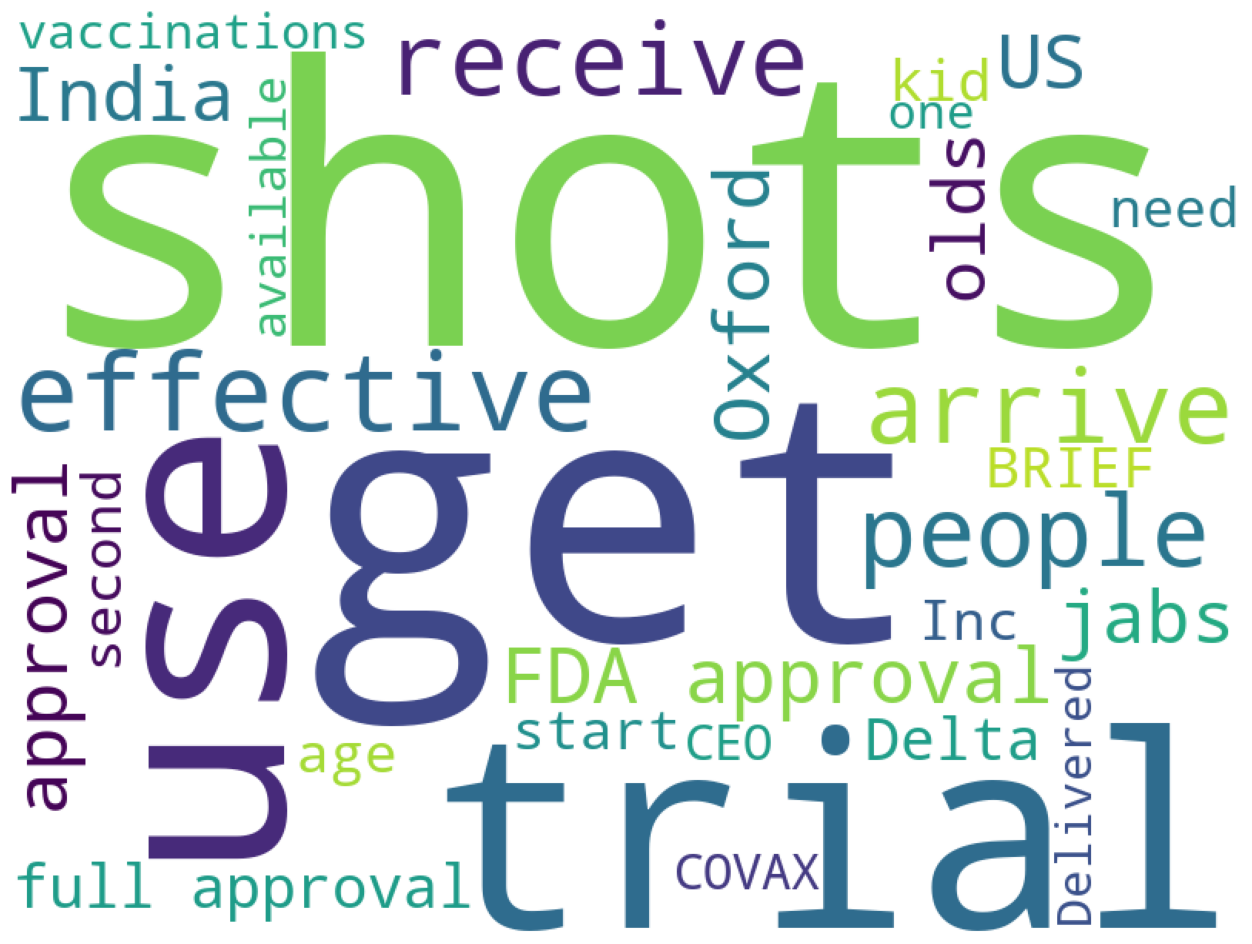

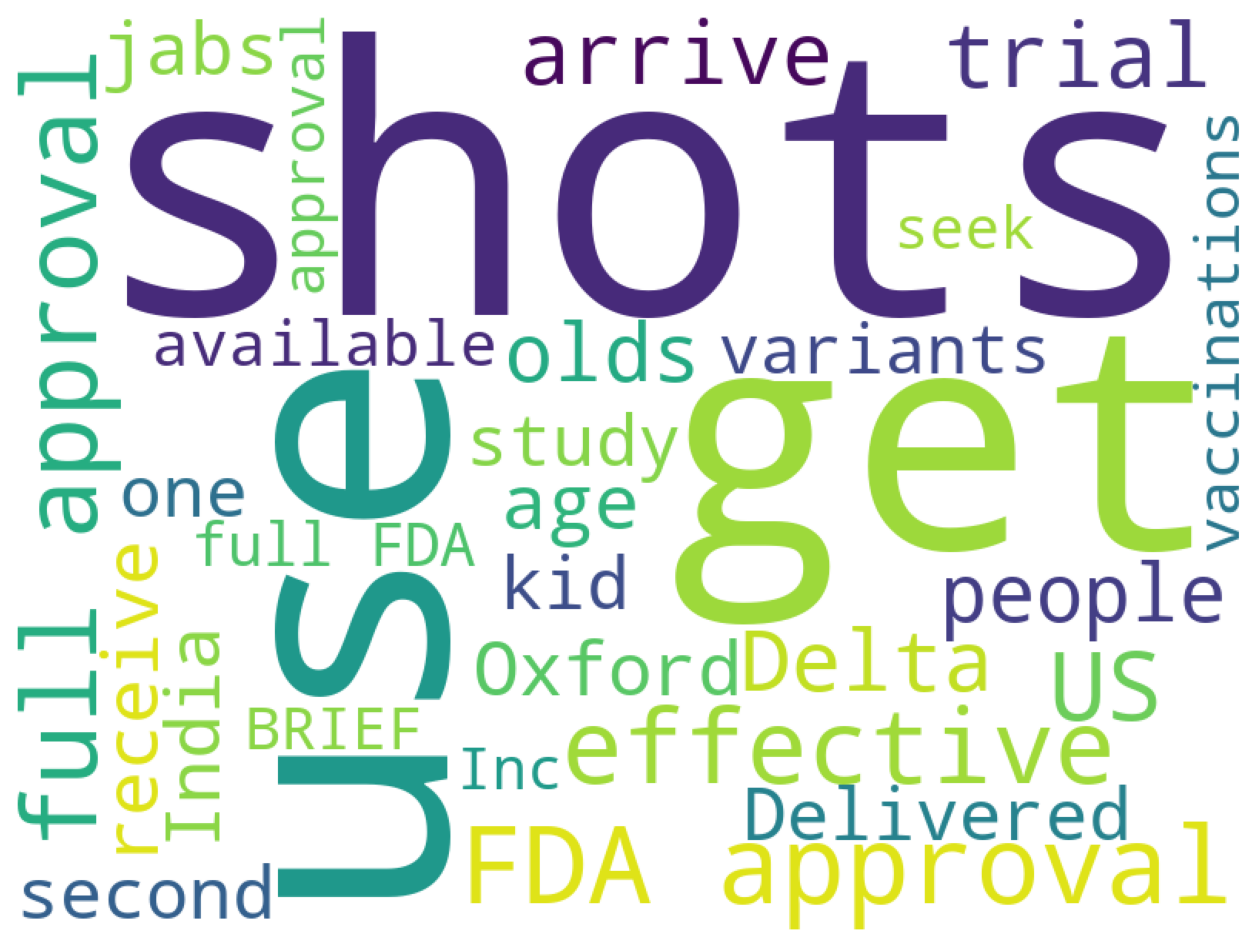

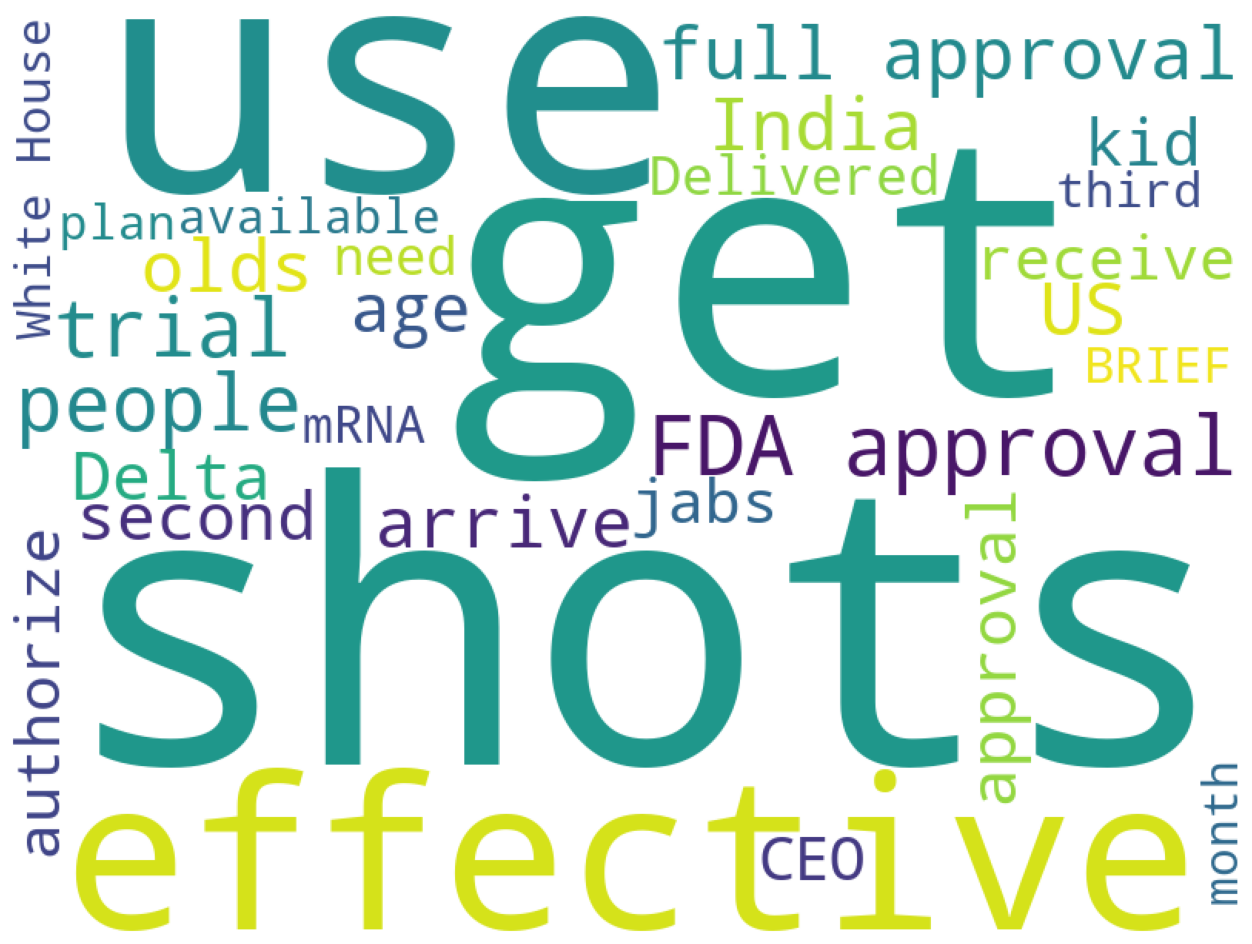

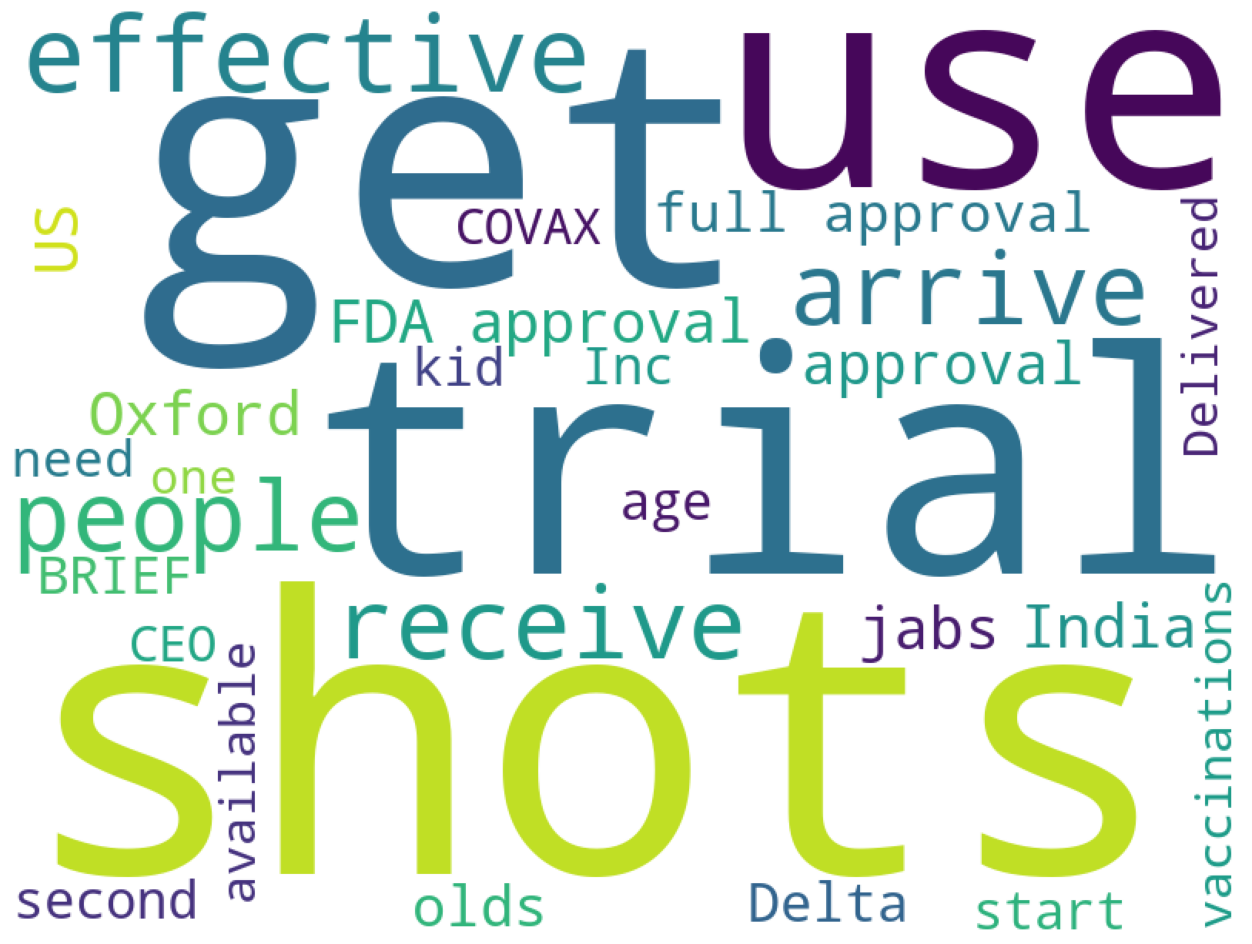

In [18]:
wc_trial = WordCloud(stopwords=stoplist, 
                        width=800, 
                        height=600,
                        max_words=30,
                        background_color="white").generate(' '.join(merged_df.trial))

figure(figsize=(16,12))
plt.imshow(wc_trial, )
plt.axis('off')
plt.show()

wc_promise = WordCloud(stopwords=stoplist, 
                        width=800, 
                        height=600,
                        max_words=30,
                        background_color="white").generate(' '.join(merged_df.promise))

figure(figsize=(16,12))
plt.imshow(wc_promise, )
plt.axis('off')
plt.show()

wc_mrna = WordCloud(stopwords=stoplist, 
                        width=800, 
                        height=600,
                        max_words=30,
                        background_color="white").generate(' '.join(merged_df.mrna))

figure(figsize=(16,12))
plt.imshow(wc_mrna, )
plt.axis('off')
plt.show()



wc_trial = WordCloud(stopwords=stoplist, 
                        width=800, 
                        height=600,
                        max_words=30,
                        background_color="white").generate(' '.join(merged_df.trial))

figure(figsize=(16,12))
plt.imshow(wc_trial, )
plt.axis('off')
plt.show()

In [19]:
firms = {
    'pfe_c' : ['Pfizer', 'pfizer', 'pfe', 'PFE'],
    'bntx_c' : ['BioNTech', 'biontech', 'BNTX', 'bntx'],
    'mrna_c' : ['Moderna', 'moderna', 'MRNA', 'mrna'],
    'sasy_c' : ['sanofi', 'Sanofi', 'SASY', 'sasy'],
    'gsk_c' : ['GSK', 'gsk', 'Glaxo', 'glaxo', 'GlaxoSmithKline', 'glaxosmithkline' ],
    'azn_c' : ['AstraZeneca', 'Astrazeneca', 'astrzeneca', 'AZN', 'azn'],
    'jnj_c' : ['Johnson', 'johnson', 'JNJ', 'jnj'],
    'nvax_c' : ['Novavax', 'novavax', 'NVAX', 'nvax']
}

to_drop = ['BNTX_evnt', 'JNJ_evnt', 'PFE_evnt', 'NVAX_evnt', 'MRNA_evnt', 'AZN_evnt', 'SASY_evnt', 'GSK_evnt']
# to_drop = []
for firm in firms:
  merged_df[firm] = 0
  for word in firms[firm]:
    merged_df[word] = np.where(merged_df['event'].str.contains(word, case=False), 1, 0)
    merged_df[firm]+= merged_df[word]
    to_drop.append(word)
    
merged_df = merged_df.drop(columns=to_drop)